In [ ]:
import pandas as pd
import zipfile

zip_path = "/content/archive (7).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/diabetes")

import os
os.listdir("/content/diabetes")

['description.pdf', 'diabetic_data.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("/content/diabetes/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("Number of documents:", df.shape[0])

Number of documents: 101766


In [ ]:
for col in df.columns:
    print(col)

encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmitted


In [ ]:
med_cols = [
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride",
    "glipizide","glyburide","pioglitazone","rosiglitazone","acarbose",
    "miglitol","insulin"
]

df["num_active_meds"] = df[med_cols].apply(
    lambda row: sum([1 for x in row if x != "No"]), axis=1
)

In [ ]:
df["readmitted_binary"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

/tmp/ipykernel_432/1698489764.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = df.groupby("med_bin")["readmitted_binary"].mean()


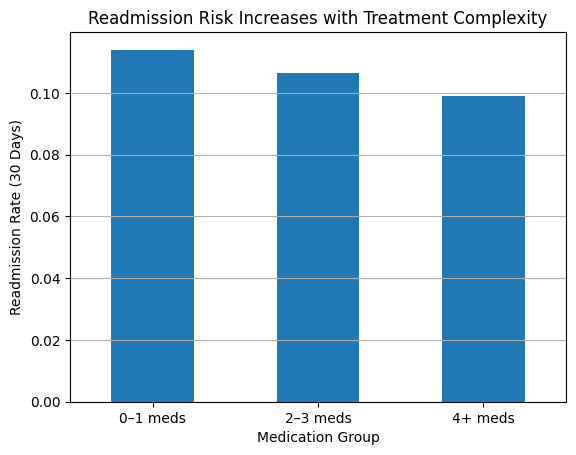

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# create bins
df["med_bin"] = pd.cut(
    df["num_active_meds"],
    bins=[-1, 1, 3, 6],
    labels=["0–1 meds", "2–3 meds", "4+ meds"]
)

# group
plot_data = df.groupby("med_bin")["readmitted_binary"].mean()

# plot
plt.figure()
plot_data.plot(kind="bar")

plt.title("Readmission Risk Increases with Treatment Complexity")
plt.xlabel("Medication Group")
plt.ylabel("Readmission Rate (30 Days)")
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

In [ ]:
med_cols = [
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride",
    "glipizide","glyburide","pioglitazone","rosiglitazone","acarbose",
    "miglitol","insulin"
]

df["num_med_changes"] = df[med_cols].apply(
    lambda row: sum([1 for x in row if x in ["Up", "Down"]]), axis=1
)

In [ ]:
df["change_bin"] = pd.cut(
    df["num_med_changes"],
    bins=[-1, 0, 2, 10],
    labels=["No Changes", "1–2 Changes", "3+ Changes"]
)

/tmp/ipykernel_432/2885777476.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = df.groupby("change_bin")["readmitted_binary"].mean()


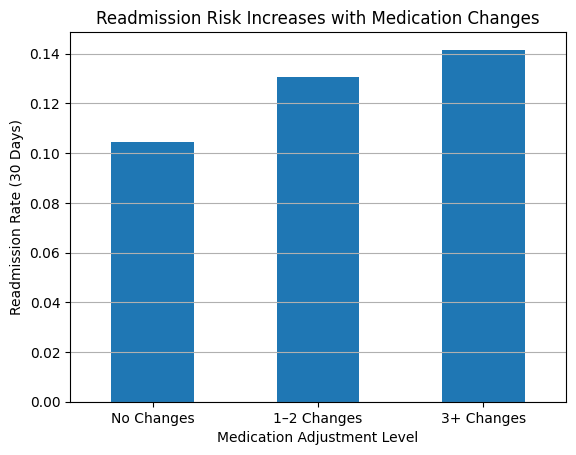

In [ ]:
import matplotlib.pyplot as plt

plot_data = df.groupby("change_bin")["readmitted_binary"].mean()

plt.figure()
plot_data.plot(kind="bar")

plt.title("Readmission Risk Increases with Medication Changes")
plt.xlabel("Medication Adjustment Level")
plt.ylabel("Readmission Rate (30 Days)")
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()